In [5]:
from collections import namedtuple
import datetime
import itertools
import json
import os
import requests
import sys

from IPython.core.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import scipy
import sklearn

os.chdir('/home/jovyan')

from lib import dataset

%matplotlib inline
%load_ext autoreload
%autoreload 2
plt.style.use("seaborn")
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 500)
display(HTML("<style>.container { width:85% !important; }</style>"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Population Data

In [83]:
data = dataset.get_csv(
    url='https://dataverse.harvard.edu/api/access/datafile/3444051?format=original',
    name='presidential_election_results'
)
data.head(3)

Using cached file cache/presidential_election_results.csv


,year,state,state_po,state_fips,state_cen,state_ic,office,candidate,party,writein,candidatevotes,totalvotes,version,notes
0,1976,Alabama,AL,1,63,41,US President,"Carter, Jimmy",democrat,False,659170,1182850,20171015,NaN
1,1976,Alabama,AL,1,63,41,US President,"Ford, Gerald",republican,False,504070,1182850,20171015,NaN
2,1976,Alabama,AL,1,63,41,US President,"Maddox, Lester",american independent party,False,9198,1182850,20171015,NaN


In [85]:
party_mapping = {
    'democratic-farmer-labor': 'democrat',
}

# Add party colors
party_colors = {'republican': 'darkred', 'democrat': 'blue', 'other': 'gray'}
parties = sorted(list(party_colors.keys()))

def get_party_group(party):
    if party in ('republican', 'democrat'):
        return party
    else:
        return party_mapping.get(party, 'other')

data_with_parties = data
data_with_parties.loc[:, 'party_group'] = data['party'].apply(get_party_group)
data_with_parties.loc[:, 'party_group_color'] = data['party_group'].map(lambda x: party_colors[x])

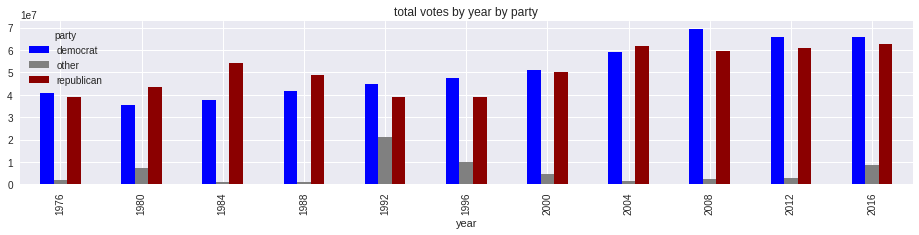

In [86]:
# How many voted for each party?
# TODO: join in number of nonvoters
national_by_year = data_with_parties.pivot_table(
    index='year', 
    columns='party_group', 
    values='candidatevotes', 
    aggfunc='sum'
).rename_axis(columns='party')

national_by_year.plot(
    kind='bar', 
    figsize=(16, 3),
    color=[party_colors[c] for c in national_by_year.columns],
    sort_columns=True)
plt.title('total votes by year by party');

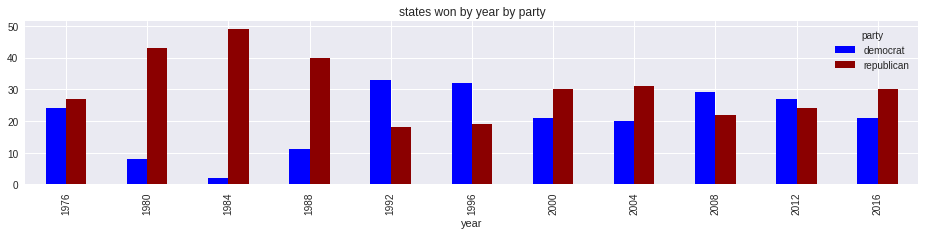

In [87]:
# How many states went for each party?
# Ignoring a couple small idiosyncracies like:
# https://en.wikipedia.org/wiki/Nebraska%27s_2nd_congressional_district
# Hack to get largest row in each group...

states_by_year = (data_with_parties
    .sort_values('candidatevotes', ascending=False)
    .groupby(['year', 'state'])['party_group'].first()
    .reset_index())

state_counts_by_year = (states_by_year
    .pivot_table(
         index='year',
         columns='party_group',
         values='state',
         aggfunc='count')
    .fillna(0))

(state_counts_by_year
     .rename_axis(columns='party')
     .plot(
         kind='bar', 
         figsize=(16, 3), 
         color=[party_colors[c] for c in state_counts_by_year.columns],
         title='states won by year by party',
         sort_columns=True
     )
);

# Fairness

How do we measure how fair an election or a voting system turned out to be?

We might want to think about:
  - consider the electoral college
  - plurality system (will need approximate data on second-preferences)
  - counts of supposed nonvoters due to their votes being wasted
  - estimates of counts of tactical voters / incentives to vote tactically
  - weighting of swing states
  - apportionment between different states, or years
  
---
We'll assume that a two-candidate first-past-the-post election with 100% turnout is perfectly fair, and then examine how unfair US elections actually are as we add in the details of the real world.

Let's start with a relatively simple case. The US presidential election. For now, ignoring non-voters and limiting to the two major candidates - we'll try to add those in later. 

How can we define the value of a single vote in terms that match intuition? 

Per "one person, "one vote", the correct value of a single vote should be $1$ in some units. Another fair number would be $\frac{1}{\text{the voting population}}$. The actual units are irrelevant, since what's going to important for any conclusions is the relevant values of different voters - whether any vote is more impactful than another.

Here's a candidate measure of fairness for this simple case:

> The value of a specific vote is inversely proportional to the number of identical voters with that preference that would need to be added or removed to change the result of the election

For example, suppose a national popular election ends up with 55 votes for party A and 45 votes for party B. If 10 voters were added to A or removed from B, the outcome would change (to a tie, which will be irrelevant with larger populations) - we get $\frac{1}{10}$ as the value of either party's vote - not very meaningful on its own, but importantly each voter's value is the _same_.

- This seems reasonable for determining relative value, but what's a reasonable way to convert this to units so that it equals $1$?
- Is it reasonable for the value of a vote to depend exact results of the election? We're trying to measure the fairness of actual elections accounting for malapportionment, gerrymandering, and the electoral college, among other things - the latter two are intuitively unfair but exactly how injustice is done depends on election results - so yes.
- Could instead multiple this by two to represent:
> The value of a specific vote is inversely proportional to the number of identical voters with that preference that would have to change to affect the result of the election.


## Applying this to the U.S. presidential election

We expect to see an effect matching intuition that voting in a non-swing states is not as valuable.

We can incorporate the electoral college like this:

$$
\text{relative value of a voter} \propto \frac{1}{\text{state's spread in votes}} \times \text{state's electoral college votes}
\times \frac{1}{\text{electoral college spread}}
$$

And since the last term is the same for all voters we can drop it.


### Electoral College Data


We'll need yearly electoral college vote counts, and we'll need to handle (or ignore) the two states that assign EC votes differently - let's ignore for now.

I got electoral college counts off [wikipedia](https://en.wikipedia.org/wiki/United_States_Electoral_College),  
cleaned them up in [this google sheet](https://docs.google.com/spreadsheets/d/1W9iLyLYCgVF3O3Hmk4k8yAXwjJAOQGiOFhnb8D6cUjk/edit?usp=sharing), and copied them into a CSV.

In [88]:
apportionment_data = pd.read_csv('data/electoral_apportionment.csv')
apportionment_by_year = apportionment_data.melt(
    id_vars='state', var_name='year', value_name='electors'
)
apportionment_by_year['year'] = apportionment_by_year['year'].astype(int)
apportionment_by_year.head(1)

,state,year,electors
0,Alabama,1976,9


In [77]:
state_electors = states_by_year.merge(apportionment_by_year, how='left', on=['year', 'state'])
assert state_electors.isnull().sum().sum() == 0
state_electors.head(1)

,year,state,party_group,electors
0,1976,Alabama,democrat,9


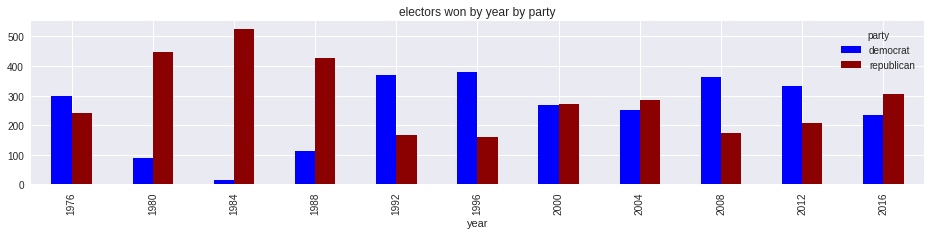

In [78]:
state_electors_by_year = (state_electors
    .pivot_table(
        index='year', 
        columns='party_group',
        values='electors',
        aggfunc='sum'
    )
    .fillna(0)
)
(state_electors_by_year
     .rename_axis(columns='party')
     .plot(
         kind='bar', 
         figsize=(16, 3), 
         color=[party_colors[c] for c in state_electors_by_year.columns],
         title='electors won by year by party',
         sort_columns=True
     )
);


In [103]:
# get to year | state | democrat count | republican count

top_two_parties_data = data_with_parties[data_with_parties['party_group'].isin(['democrat', 'republican'])]
state_votes = top_two_parties_data.pivot_table(
    index=['year', 'state'], 
    columns='party_group',
    values='candidatevotes',
    aggfunc='sum'
).reset_index()

state_votes_with_electors = state_votes.merge(apportionment_by_year, how='left', on=['year', 'state'])

state_votes_with_electors['spread'] = \
  np.abs(state_votes_with_electors['democrat'] - state_votes_with_electors['republican'])
state_votes_with_electors['relative_value'] = (
  state_votes_with_electors['electors'] / state_votes_with_electors['spread']
)
state_votes_with_electors['normalized_relative_value'] = (
    state_votes_with_electors['relative_value'] / min(state_votes_with_electors['relative_value'])
)

In [107]:
state_votes_with_electors[state_votes_with_electors.year==2016].sort_values('normalized_relative_value', ascending=False)

,year,state,democrat,republican,electors,spread,relative_value,normalized_relative_value
532,2016,Michigan,2268839,2279543,16,10704,0.001495,134.582461
539,2016,New Hampshire,348526,345790,4,2736,0.001462,131.631092
548,2016,Pennsylvania,2926441,2970733,20,44292,0.000452,40.655498
559,2016,Wisconsin,1382536,1405284,10,22748,0.000440,39.579597
519,2016,Florida,4504975,4617886,29,112911,0.000257,23.124712
533,2016,Minnesota,1367705,1322949,10,44756,0.000223,20.117005
538,2016,Nevada,539260,512058,6,27202,0.000221,19.859349
529,2016,Maine,357735,335593,4,22142,0.000181,16.265137
512,2016,Arizona,1161209,1252401,11,91192,0.000121,10.860518
543,2016,North Carolina,2189316,2362631,15,173315,0.000087,7.792372
